# Day 52: Linear Regression — sklearn Implementation
**Phase 4 · Machine Learning · 90-Day Data Science Roadmap**

## Objective
- Fit a `LinearRegression` model with `fit()` and make predictions with `predict()`
- Read the learned weights with `coef_` and `intercept_`
- Measure the model with three metrics: **RMSE**, **MAE** and **R²**
- Draw a **residual plot** and check whether the errors look random
- Dataset: synthetic FC Lahore Lions player seasons (goals predicted from match stats)

## Imports

In [1]:
# Data tools
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt

# sklearn: the model, the splitter and the metrics
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## Theory
**Beginner version**
- On Day 51 we built linear regression by hand: guess weights, measure the error (MSE), walk downhill (gradient descent).
- `sklearn` does that work for us. `LinearRegression` finds the best weights directly, so the coding is only a few lines.
- The real skill today is **reading the results**, not just getting a number.

**The model (same as Day 51)**
- `goals = w1 * shots_on_target + w2 * key_passes + w3 * matches_played + b`
- Each weight `w` = how many extra goals we expect when that feature goes up by 1 (others held fixed)
- `b` (the intercept) = the predicted goals when every feature is 0

**Deeper version**
- `LinearRegression` solves ordinary least squares (minimizes MSE) with a direct linear-algebra solution, not gradient descent. Both reach the same bottom of the MSE bowl.
- After `fit()`, sklearn stores learned values on the model with a trailing underscore: `coef_` and `intercept_`.

**The 4-step workflow**
1. Split the data (`train_test_split`)
2. `model.fit(X_train, y_train)`
3. `model.predict(X_test)`
4. Evaluate on the **test** set (RMSE, MAE, R²) and check residuals

## Dataset
- 500 synthetic player-seasons for FC Lahore Lions (`np.random.seed(42)`, so the results repeat every run)
- Features: `shots_on_target`, `key_passes`, `matches_played`
- Target: `goals`
- We generate the data with known "true" weights (0.30, 0.08, 0.15 and intercept 1.0) so we can check that the model recovers them

In [2]:
# Fix the random seed so everyone gets the same numbers
np.random.seed(42)
n = 500

# Build the three features
shots_on_target = np.random.randint(10, 81, n)
key_passes = np.random.randint(5, 61, n)
matches_played = np.random.randint(10, 39, n)

# Build goals from a known rule plus random noise (real life is never perfect)
noise = np.random.normal(0, 3, n)
goals = 1.0 + 0.30 * shots_on_target + 0.08 * key_passes + 0.15 * matches_played + noise

# Put everything in a DataFrame; goals must be whole numbers and never below 0
df = pd.DataFrame({
    "shots_on_target": shots_on_target,
    "key_passes": key_passes,
    "matches_played": matches_played,
    "goals": np.clip(goals.round(), 0, None).astype(int),
})

# Save a copy for the GitHub folder
df.to_csv("lions_player_seasons.csv", index=False)
df.head()

,shots_on_target,key_passes,matches_played,goals
0,61,43,17,28
1,24,31,23,15
2,70,14,28,29
3,30,30,38,17
4,33,23,15,18


## Example 1: Fit, Predict and Read the Coefficients
- **Step 1:** separate features (`X`) from the target (`y`), then split 80% train / 20% test
- **Step 2:** `fit()` learns the weights from the training data only
- **Step 3:** `predict()` gives goal predictions for players the model has never seen

In [3]:
# X = the input columns, y = the thing we want to predict
X = df[["shots_on_target", "key_passes", "matches_played"]]
y = df["goals"]

# Split: 80% to learn from, 20% kept hidden for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create the model, then learn from the training data
model = LinearRegression()
model.fit(X_train, y_train)

# Predict goals for the unseen test players
y_pred = model.predict(X_test)

# Compare the first 5 predictions with the real goals
comparison = pd.DataFrame({
    "actual_goals": y_test.values[:5],
    "predicted_goals": y_pred[:5].round(1),
})
comparison

,actual_goals,predicted_goals
0,29,30.9
1,22,21.7
2,34,30.1
3,7,7.8
4,16,18.1


### Reading the coefficients
- `model.coef_` holds one weight per feature, in the same order as the columns of `X`
- `model.intercept_` is the bias `b`
- Careful: comparing raw weights across features with different scales can mislead. A shot is counted in tens, a match in ones.
- Fair comparison: multiply each weight by the feature's standard deviation. That answers "how many goals does a typical swing in this feature move?"

In [4]:
# Pair each weight with its feature name
coef_table = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_.round(3),
})

# Extra column: weight x standard deviation = fair "typical impact" comparison
coef_table["typical_impact_goals"] = (model.coef_ * X_train.std().values).round(2)

print(coef_table)
print("intercept:", round(model.intercept_, 3))

           feature  coefficient  typical_impact_goals
0  shots_on_target        0.312                  6.42
1       key_passes        0.071                  1.19
2   matches_played        0.142                  1.20
intercept: 0.972


## Example 2: Metrics — RMSE, MAE and R²
- **RMSE** = square root of the mean squared error. Same unit as the target (goals). It punishes big misses more.
- **MAE** = average size of the miss, in goals. Easy to explain to anyone.
- **R²** = share of the variation in goals that the model explains. 1.0 = perfect, 0 = no better than always guessing the average.
- Always compute metrics on the **test** set. Comparing train vs test (Day 50 idea) shows overfitting.

In [5]:
# Error in goals
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

# Share of variation explained (test set, then train set for comparison)
r2_test = r2_score(y_test, y_pred)
r2_train = r2_score(y_train, model.predict(X_train))

print("RMSE:", round(rmse, 2), "goals")
print("MAE :", round(mae, 2), "goals")
print("R2 (test) :", round(r2_test, 3))
print("R2 (train):", round(r2_train, 3))

RMSE: 2.81 goals
MAE : 2.34 goals
R2 (test) : 0.857
R2 (train): 0.834


## Practice Exercise: Residual Plot
- Residual = `actual - predicted` (how far off each prediction was)
- Plot residuals (y-axis) against predictions (x-axis) and add a line at 0
- **Random scatter around 0** = the model captured the pattern
- **A curve, funnel or trend** = the model is missing something (for example a non-linear relationship)
- With 500 seasons, the test set has 100 players, enough dots to judge the shape (a tiny test set can look lopsided by pure chance)
- Try it yourself first, then compare with the solution below

mean residual: -0.18


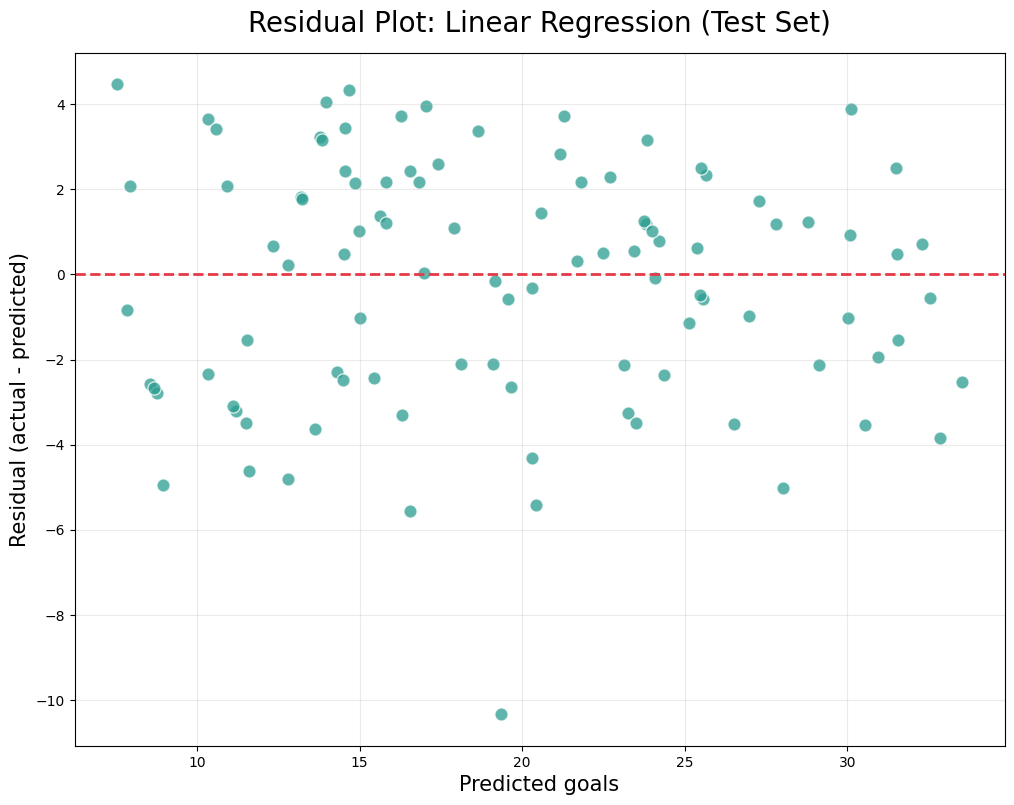

In [6]:
# Residuals: actual minus predicted
residuals = y_test - y_pred

# Draw the plot
plt.figure(figsize=(12, 9))
plt.scatter(y_pred, residuals, color="#2a9d8f", alpha=0.75, edgecolor="white", s=90)

# Reference line: perfect predictions would sit exactly on 0
plt.axhline(0, color="#e63946", linestyle="--", linewidth=2)

# Labels and title
plt.title("Residual Plot: Linear Regression (Test Set)", fontsize=20, pad=15)
plt.xlabel("Predicted goals", fontsize=15)
plt.ylabel("Residual (actual - predicted)", fontsize=15)
plt.grid(alpha=0.25)

# Average residual should sit close to 0 for a well-fitted model
print("mean residual:", round(residuals.mean(), 2))

# Save the image for the repo, then show it
plt.savefig("images/day_52_residual_plot.png", dpi=100)
plt.show()

**How to read it:** the points form a shapeless cloud around the red zero line with no curve or funnel. That is what a healthy linear model looks like.

## Mini Challenge: Does Adding Features Help?
- Fit a second model that uses **only** `shots_on_target`
- Compare its test R² and RMSE with the 3-feature model
- Question to answer: are `key_passes` and `matches_played` worth keeping?

In [7]:
# Model B: one feature only
X_train_one = X_train[["shots_on_target"]]
X_test_one = X_test[["shots_on_target"]]

model_one = LinearRegression()
model_one.fit(X_train_one, y_train)
pred_one = model_one.predict(X_test_one)

# Side-by-side scoreboard
scoreboard = pd.DataFrame({
    "model": ["1 feature (shots only)", "3 features (all)"],
    "R2_test": [round(r2_score(y_test, pred_one), 3), round(r2_test, 3)],
    "RMSE_goals": [
        round(np.sqrt(mean_squared_error(y_test, pred_one)), 2),
        round(rmse, 2),
    ],
})
scoreboard

,model,R2_test,RMSE_goals
0,1 feature (shots only),0.818,3.18
1,3 features (all),0.857,2.81


## Summary
- `LinearRegression().fit(X_train, y_train)` learns the weights; `.predict(X_test)` makes predictions
- `coef_` = effect of each feature, `intercept_` = starting value; compare features fairly by accounting for scale
- RMSE and MAE are errors in the target's unit (goals); R² is the share of variation explained
- A residual plot with random scatter around 0 means a linear model fits; a visible pattern means it does not
- Always evaluate on the test set, and compare with the train score to spot overfitting
- **Next (Day 53):** Ridge and Lasso, regularization to handle correlated or too many features